# Boxplots y evolución — GHAW-H (Tarea 5)

Este notebook construye los boxplots y la inspección de casos que explican
cómo cambian los archivos Markdown de GH-AW entre versiones, a partir de las
tablas generadas por `01_preparacion_y_agregaciones.ipynb`. Carga sus
entradas únicamente desde `data/processed/*.parquet` (y, solo en la Sección
5, desde `data/raw/*.parquet` para extraer fragmentos de contenido) — no
depende de ninguna variable en memoria del primer notebook.

## 1. Carga y descripción de las medidas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

from pathlib import Path
PROCESSED_DIR = Path("data/processed")
RAW_DIR = Path("data/raw")

version_measures = pd.read_parquet(PROCESSED_DIR / "version_measures.parquet")
transitions = pd.read_parquet(PROCESSED_DIR / "transitions.parquet")
file_summary = pd.read_parquet(PROCESSED_DIR / "file_summary.parquet")
file_month_summary = pd.read_parquet(PROCESSED_DIR / "file_month_summary.parquet")

for name, df in [("version_measures", version_measures), ("transitions", transitions),
                  ("file_summary", file_summary), ("file_month_summary", file_month_summary)]:
    print(f"{name}: {df.shape[0]} filas x {df.shape[1]} columnas")

version_measures: 2820 filas x 11 columnas
transitions: 2216 filas x 16 columnas
file_summary: 604 filas x 8 columnas
file_month_summary: 768 filas x 4 columnas


- **`version_measures`**: una fila por versión observada (2.820), con su
  longitud de body y tamaño de frontmatter.
- **`transitions`**: una fila por transición (versión con predecesor válido),
  con los identificadores de ambas versiones y las medidas de cambio.
- **`file_summary`**: una fila por historia (604), con el resumen
  primera/última versión y la mediana del tiempo entre versiones.
- **`file_month_summary`**: una fila por combinación historia-mes con al
  menos una transición ese mes.

A continuación se define una función auxiliar para acompañar cada boxplot
con su tabla de `n`, mediana, Q1, Q3 e IQR — la reutilizamos en las
Secciones 2, 3 y 4. También adelantamos cuántas observaciones válidas
alimentarán cada uno de los tres boxplots (el detalle de cómo se filtra
cada uno se explica en su propia sección).

In [2]:
n_preview_212 = int(
    ((file_summary["version_count"] >= 2)
     & file_summary["first_length"].notna()
     & file_summary["last_length"].notna()).sum()
)
n_preview_month_obs = len(file_month_summary)
n_preview_month_files = file_month_summary["history_id"].nunique()
n_preview_days = int(file_summary["median_days_between_versions"].notna().sum())

print("Observaciones válidas por gráfico:")
print(f"  Sección 2 (primera vs. última):  {n_preview_212} archivos")
print(f"  Sección 3 (variación mensual):   {n_preview_month_obs} pares archivo-mes, "
      f"de {n_preview_month_files} archivos distintos")
print(f"  Sección 4 (tiempo entre versiones): {n_preview_days} archivos")

Observaciones válidas por gráfico:
  Sección 2 (primera vs. última):  406 archivos
  Sección 3 (variación mensual):   768 pares archivo-mes, de 406 archivos distintos
  Sección 4 (tiempo entre versiones): 406 archivos


In [3]:
def quartile_stats(series):
    """n, mediana, Q1, Q3 e IQR de una serie, ignorando valores ausentes."""
    s = series.dropna()
    if len(s) == 0:
        return pd.Series({"n": 0, "mediana": np.nan, "Q1": np.nan, "Q3": np.nan, "IQR": np.nan})
    q1, med, q3 = s.quantile([0.25, 0.5, 0.75])
    return pd.Series({"n": int(len(s)), "mediana": med, "Q1": q1, "Q3": q3, "IQR": q3 - q1})

## 2. Comparación entre la primera y la última versión

Usamos `file_summary`, filtrando a historias con al menos dos versiones
y con longitud válida tanto en la primera como en la última — así ambos
grupos del boxplot contienen exactamente los mismos archivos, y la
comparación es pareada por archivo.

Historias usadas (>=2 versiones, longitud válida en ambos extremos): 406


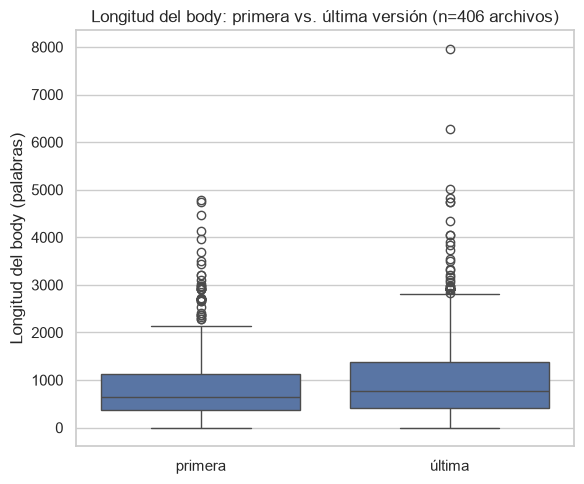

In [4]:
mask_212 = (
    (file_summary["version_count"] >= 2)
    & file_summary["first_length"].notna()
    & file_summary["last_length"].notna()
)
fs_212 = file_summary.loc[mask_212].copy()
n_212 = len(fs_212)
print(f"Historias usadas (>=2 versiones, longitud válida en ambos extremos): {n_212}")

long_212 = pd.concat([
    pd.DataFrame({"version_type": "primera", "body_length": fs_212["first_length"]}),
    pd.DataFrame({"version_type": "última", "body_length": fs_212["last_length"]}),
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=long_212, x="version_type", y="body_length", whis=1.5, ax=ax)
ax.set_title(f"Longitud del body: primera vs. última versión (n={n_212} archivos)")
ax.set_xlabel("")
ax.set_ylabel("Longitud del body (palabras)")
plt.tight_layout()
plt.show()

In [5]:
stats_212 = long_212.groupby("version_type")["body_length"].apply(quartile_stats).unstack()
stats_212

,n,mediana,Q1,Q3,IQR
version_type,,,,,
primera,406.0,641.0,364.50,1132.50,768.0
última,406.0,760.0,414.75,1375.75,961.0


La mediana sube de la primera a la última versión, y el rango
intercuartílico (IQR) también se ensancha: los archivos no solo tienden a
crecer, sino que la variabilidad entre archivos aumenta con las revisiones
— algunos crecen mucho más que otros. Esto se confirma clasificando cada
archivo individualmente por su `net_length_change`:

In [6]:
def classify_change(net_change):
    if net_change > 0:
        return "aumentó"
    if net_change < 0:
        return "disminuyó"
    return "igual"

fs_212["direction"] = fs_212["net_length_change"].map(classify_change)
counts_212 = fs_212["direction"].value_counts()
pct_212 = (counts_212 / n_212 * 100).round(1)

summary_212 = pd.DataFrame({"cantidad de archivos": counts_212, "% del total": pct_212})
summary_212

,cantidad de archivos,% del total
direction,,
aumentó,222,54.7
igual,132,32.5
disminuyó,52,12.8


La mayoría de los archivos crece (~55%), una parte importante queda
exactamente igual en longitud (~33% — recordando que "igual longitud" no
significa "sin cambios", ver Sección 3 del Notebook 1), y una minoría se
achica (~13%). Esta comparación se calculó **individualmente por archivo**:
cada historia aporta un único par (primera, última), no una transición por
cada versión intermedia.

## 3. Variación de longitud por mes

Usamos `file_month_summary`: cada archivo aporta una observación por
mes en el que tuvo al menos una transición (la mediana de la magnitud del
cambio de longitud de ese mes). Ordenamos los meses cronológicamente.

In [7]:
month_order = sorted(file_month_summary["month"].unique())
n_per_month = file_month_summary.groupby("month")["history_id"].nunique().reindex(month_order)
print("Archivos (historias) representados por mes:")
print(n_per_month.to_string())

SMALL_N_THRESHOLD = 5
small_months = n_per_month[n_per_month < SMALL_N_THRESHOLD].index.tolist()
print(f"\nMeses con menos de {SMALL_N_THRESHOLD} archivos (cobertura parcial): {small_months}")

Archivos (historias) representados por mes:
month
2025-10      3
2025-11      4
2025-12      7
2026-01      8
2026-02     74
2026-03    121
2026-04    144
2026-05    196
2026-06    211

Meses con menos de 5 archivos (cobertura parcial): ['2025-10', '2025-11']


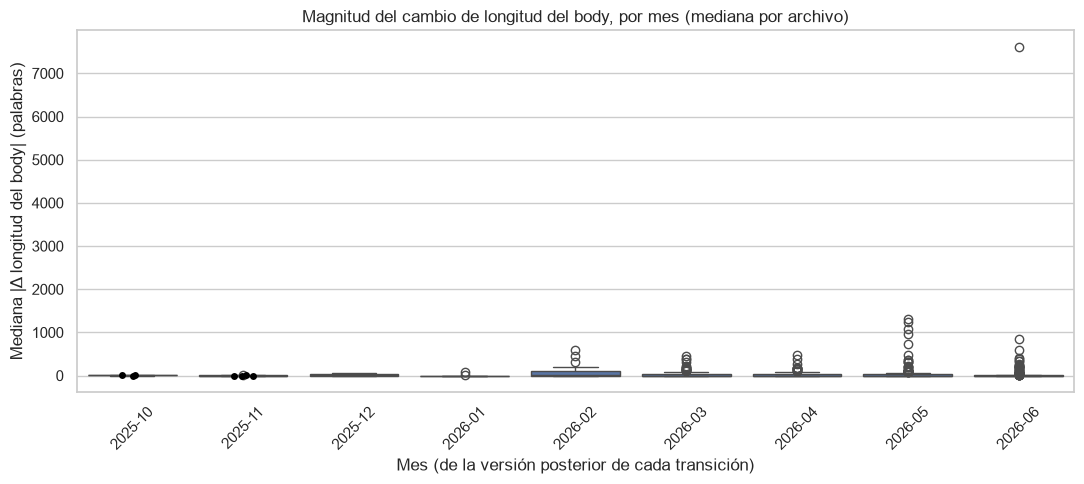

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=file_month_summary, x="month", y="median_abs_delta_body_length",
    order=month_order, whis=1.5, ax=ax,
)
# Los meses con pocas observaciones no se interpretan bien como caja: se
# superponen también los puntos individuales para no ocultar la dispersión real.
small_subset = file_month_summary[file_month_summary["month"].isin(small_months)]
sns.stripplot(
    data=small_subset, x="month", y="median_abs_delta_body_length",
    order=month_order, color="black", size=5, jitter=True, ax=ax,
)
ax.set_title("Magnitud del cambio de longitud del body, por mes (mediana por archivo)")
ax.set_xlabel("Mes (de la versión posterior de cada transición)")
ax.set_ylabel("Mediana |Δ longitud del body| (palabras)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
stats_month = (
    file_month_summary.groupby("month")["median_abs_delta_body_length"]
    .apply(quartile_stats)
    .unstack()
    .reindex(month_order)
)
stats_month.insert(0, "n_archivos", n_per_month)
stats_month

,n_archivos,n,mediana,Q1,Q3,IQR
month,,,,,,
2025-10,3,3.0,4.00,2.0,10.000,8.000
2025-11,4,4.0,0.00,0.0,2.000,2.000
2025-12,7,7.0,11.50,0.0,28.000,28.000
2026-01,8,8.0,0.00,0.0,0.875,0.875
2026-02,74,74.0,9.75,0.0,98.375,98.375
2026-03,121,121.0,1.00,0.0,39.000,39.000
2026-04,144,144.0,0.00,0.0,38.000,38.000
2026-05,196,196.0,0.00,0.0,28.000,28.000
2026-06,211,211.0,0.00,0.0,4.750,4.750


Octubre y noviembre de 2025 tienen muy pocos archivos representados
(3 y 4) — son los primeros meses del dataset, con adopción temprana de
GH-AW todavía muy baja, así que sus cajas describen apenas un puñado de
archivos y se muestran también como puntos individuales en el gráfico. La
cantidad de archivos activos crece fuertemente mes a mes, reflejando la
adopción creciente de GH-AW más que un cambio de comportamiento de edición.

Tanto el mes inicial como el final tienen cobertura **parcial**: 2025-10
solo cubre desde el 3 de octubre (fecha de la versión más antigua del
dataset), y 2026-06 solo cubre hasta el 27 de junio (fecha de la versión
más reciente, y también el corte de esta instantánea de GHAW-H) — ninguno
de los dos es un mes calendario completo, así que sus conteos y cajas no
son directamente comparables con los meses intermedios, que sí están
completos.

La mediana de muchos meses está en o cerca de 0 —la mayoría de los
archivos activos en un mes dado no cambia mucho ese mes—, pero el Q3 y el
bigote superior son mucho más altos, indicando una minoría de archivos con
reescrituras grandes en ese período. Como los archivos presentes varían de
mes a mes (no es el mismo panel de archivos todos los meses), estas cajas
no deben leerse como una serie de tiempo de "el mismo conjunto de archivos
cambiando progresivamente", sino como una foto por mes de qué tanto
cambiaron los archivos que tuvieron alguna transición ese mes.

## 4. Tiempo entre versiones

Usamos `file_summary["median_days_between_versions"]`, que solo tiene
valor para historias con al menos una transición válida (los mismos 406
archivos de la Sección 2).

Historias con tiempo entre versiones calculable: 406


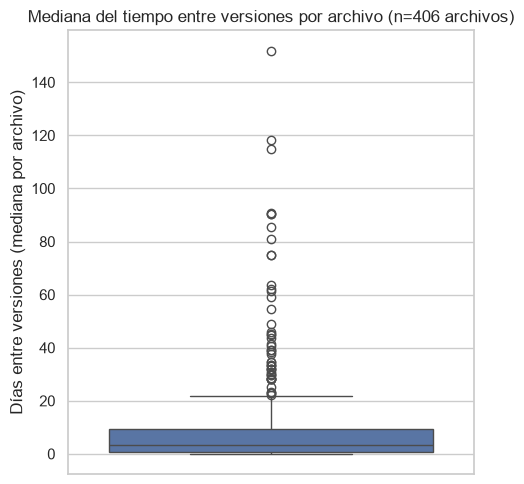

In [10]:
days_series = file_summary["median_days_between_versions"].dropna()
n_days = len(days_series)
print(f"Historias con tiempo entre versiones calculable: {n_days}")

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(y=days_series, whis=1.5, ax=ax)
ax.set_title(f"Mediana del tiempo entre versiones por archivo (n={n_days} archivos)")
ax.set_xlabel("")
ax.set_ylabel("Días entre versiones (mediana por archivo)")
plt.tight_layout()
plt.show()

In [11]:
stats_days = quartile_stats(days_series).to_frame("median_days_between_versions").T
stats_days

,n,mediana,Q1,Q3,IQR
median_days_between_versions,406.0,3.447164,0.824074,9.329479,8.505405


In [12]:
q1, q3 = days_series.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"Bigotes (1.5xIQR): [{lower_fence:.2f}, {upper_fence:.2f}] días")

history_labels = version_measures.groupby("source_markdown_file_history_id")[
    ["repo_full_name", "path"]
].first()

high_outliers = file_summary[file_summary["median_days_between_versions"] > upper_fence]
print(f"\nArchivos por encima del bigote superior ({len(high_outliers)} de {n_days}):")
top_high = (
    high_outliers.merge(history_labels, left_on="history_id", right_index=True)
    .nlargest(5, "median_days_between_versions")
    [["repo_full_name", "path", "median_days_between_versions", "version_count"]]
)
display(top_high)

print("\nArchivos con el tiempo entre versiones más bajo (no son outliers estadísticos, "
      "el bigote inferior es negativo, pero sí son extremos en términos prácticos):")
low_extreme = (
    file_summary.dropna(subset=["median_days_between_versions"])
    .merge(history_labels, left_on="history_id", right_index=True)
    .nsmallest(5, "median_days_between_versions")
    [["repo_full_name", "path", "median_days_between_versions", "version_count"]]
)
display(low_extreme)

Bigotes (1.5xIQR): [-11.93, 22.09] días

Archivos por encima del bigote superior (48 de 406):


,repo_full_name,path,median_days_between_versions,version_count
603,drasi-project/drasi-server,.github/workflows/validate-yaml-snippets.md,151.929051,2
369,Azure/typespec-azure,.github/workflows/docs-sync.md,118.212894,2
86,PowerShell/vscode-powershell,.github/workflows/issue-triage.md,114.802141,2
451,kubestellar/docs,.github/workflows/devstats.md,90.918935,3
508,chrisreddington/flight-school,.github/workflows/daily-accessibility-review.md,90.244213,2



Archivos con el tiempo entre versiones más bajo (no son outliers estadísticos, el bigote inferior es negativo, pero sí son extremos en términos prácticos):


,repo_full_name,path,median_days_between_versions,version_count
594,felipementel/GitHubCopilotDevDays-Curitiba-2026,.github/workflows/pull-request-opened.md,0.000903,2
487,meteostat/meteostat,.github/workflows/bug-reproducer.md,0.001563,2
564,inference-sh/shadcn-registry,.github/workflows/code-review.md,0.001829,2
65,taosdata/TDengine,.github/workflows/issue-triage.md,0.002535,2
320,microsoft/finnts,.github/workflows/repo-improver.md,0.002674,3


La mediana global (~3,4 días) y un IQR amplio (~8,5 días) muestran una
distribución con cola larga hacia la derecha: la mayoría de los archivos se
revisan cada pocos días, pero hay un grupo no menor (48 de 406, el bigote
superior cae en torno a los 22 días) que tarda semanas o meses entre
versiones — por ejemplo `drasi-project/drasi-server` (~152 días) o
`Azure/typespec-azure` (~118 días), consistentes con mantenimiento
esporádico en vez de iteración activa. En el extremo opuesto, varios
archivos muestran intervalos de minutos (p. ej. `felipementel/...`, menos
de un minuto) — probablemente commits consecutivos de prueba/ajuste del
mismo cambio, no "versiones" con intención independiente. No son outliers
estadísticos porque el bigote inferior calculado con la regla de 1,5×IQR es
negativo (no hay un piso natural para un intervalo de tiempo), pero igual
conviene señalarlos: **estos resultados describen únicamente las versiones
observadas en el dataset**, no necesariamente la cadencia real de edición
del archivo (podría haber commits intermedios sin GH-AW válido, o el
archivo podría no haberse tocado fuera de la ventana capturada por GHAW-H).

## 5. Inspección de casos

Elegimos dos transiciones reales (sin necesidad de un caso de
respaldo): la de mayor magnitud de cambio de longitud del body, y una con
cambio en la cantidad de claves del frontmatter (372 transiciones cumplen
esta condición). Para ver el contenido real de ambas versiones recargamos
`source_markdown_file_version.parquet` y `source_markdown_file_snapshot.parquet`
desde `data/raw/` — las tablas procesadas no incluyen el texto completo.

In [13]:
raw_version = pd.read_parquet(RAW_DIR / "source_markdown_file_version.parquet")
raw_snapshot = pd.read_parquet(RAW_DIR / "source_markdown_file_snapshot.parquet")

def get_content(version_id):
    vid = int(version_id)
    snap_id = raw_version.loc[
        raw_version["source_markdown_file_version_id"] == vid, "source_markdown_file_snapshot_id"
    ].iloc[0]
    row = raw_snapshot.loc[raw_snapshot["source_markdown_file_snapshot_id"] == snap_id].iloc[0]
    return row["frontmatter"], row["body"]

case_a = transitions.nlargest(1, "abs_delta_body_length").iloc[0]

fm_change = transitions[transitions["delta_frontmatter_size"] != 0].copy()
fm_change["abs_delta_frontmatter_size"] = fm_change["delta_frontmatter_size"].abs()
case_b = fm_change.nlargest(1, "abs_delta_frontmatter_size").iloc[0]

print("Caso A: mayor magnitud de cambio de longitud del body")
print(case_a[["repo_full_name", "path", "predecessor_version_id", "version_id",
              "predecessor_committed_at", "committed_at",
              "predecessor_body_length", "body_length", "abs_delta_body_length"]])

print("\nCaso B: mayor cambio en cantidad de claves del frontmatter")
print(case_b[["repo_full_name", "path", "predecessor_version_id", "version_id",
              "predecessor_committed_at", "committed_at",
              "predecessor_frontmatter_size", "frontmatter_size", "delta_frontmatter_size"]])

Caso A: mayor magnitud de cambio de longitud del body
repo_full_name                                           dotnet/fsharp
path                        .github/workflows/agentic-state-machine.md
predecessor_version_id                                          1389.0
version_id                                                        1390
predecessor_committed_at                     2026-05-28 16:43:16+00:00
committed_at                                 2026-06-16 09:00:03+00:00
predecessor_body_length                                          336.0
body_length                                                       7949
abs_delta_body_length                                           7613.0
Name: 1066, dtype: object

Caso B: mayor cambio en cantidad de claves del frontmatter
repo_full_name                                         pydantic/pydantic-ai
path                            .github/workflows/pydantic-ai-bug-hunter.md
predecessor_version_id                                               

In [14]:
fm_a_pred, body_a_pred = get_content(case_a["predecessor_version_id"])
fm_a_cur, body_a_cur = get_content(case_a["version_id"])

print("=== Caso A: extracto del body ANTES (primeras 400 palabras aprox.) ===")
print(body_a_pred[:600])
print("\n=== Caso A: extracto del body DESPUÉS (mismo punto de partida) ===")
print(body_a_cur[:600])

=== Caso A: extracto del body ANTES (primeras 400 palabras aprox.) ===

# Agentic State Machine — Diagram Generator

<role>
You read all agentic workflow `.md` files in `.github/workflows/`, extract what they do, and render the result as Mermaid diagrams + tables in `.github/docs/state-machine.md`.
</role>

<rules>
1. Read ALL `.md` files in `.github/workflows/` except `shared/`, `docs/`, and `agentic-state-machine.md` (this file).
2. If `.github/docs/state-machine.md` exists, read it. Compare source hashes in the `<!-- sources: ... -->` footer against current files (use `sha256sum`). If unchanged → `noop`. If changed → update incrementally, minimal diff.
3. Ever

=== Caso A: extracto del body DESPUÉS (mismo punto de partida) ===

# Agentic State Machine — Diagram Generator

<role>
You are a workflow-automation documentor. You read all workflow files in `.github/workflows/`, build a structured model of their interactions, validate it adversarially, and render the result as Mermaid diag

**Caso A** (`dotnet/fsharp`, `.github/workflows/agentic-state-machine.md`):
el body pasó de 336 a 7.949 palabras (+7.613). El extracto muestra que no es
relleno: la versión predecesora tenía un rol y reglas breves ("lee los
workflows y genera un diagrama"), mientras que la versión nueva expande esas
mismas reglas en secciones muy detalladas ("Extraction rules", prohibiciones
explícitas de inferencia/alucinación, checklists de validación para cada
tipo de nodo del diagrama). Es una reescritura hacia un prompt mucho más
prescriptivo y estructurado, no una simple repetición de contenido.

In [15]:
fm_b_pred, _ = get_content(case_b["predecessor_version_id"])
fm_b_cur, _ = get_content(case_b["version_id"])

print("=== Caso B: frontmatter ANTES ===")
print(fm_b_pred)
print("\n=== Caso B: frontmatter DESPUÉS ===")
print(fm_b_cur)

=== Caso B: frontmatter ANTES ===
emoji: "🐛"
name: "Pydantic AI Bug Hunter"
description: "Find a reproducible, user-impacting bug in pydantic-ai and file a report issue. Runs on the Pydantic AI gh-aw shim; the task prompt is iterable from a Logfire managed variable."
# Fuzzy schedule: gh-aw scatters the daily run to a repo-stable off-peak time
# (avoids the top-of-hour stampede) and auto-adds workflow_dispatch.
on: daily
permissions:
  contents: read
  issues: read
  pull-requests: read
# Full git history: the agent's repo checkout is shallow by default, so
# `git log --since=...` would see only the tip commit. fetch-depth: 0 gives
# the agent the real commit history it needs to find recent changes.
checkout:
  fetch-depth: 0
concurrency:
  group: ${{ github.workflow }}-bug-hunter
  cancel-in-progress: true
network:
  allowed:
    - defaults
    # Python/PyPI ecosystem — the harness installs its deps via `uv` at agent
    # time; allow them through the AWF firewall. (`defaults` already

**Caso B** (`pydantic/pydantic-ai`,
`.github/workflows/pydantic-ai-bug-hunter.md`): el frontmatter pasó de 17 a
11 claves de primer nivel (−6). Comparando ambas versiones, las claves
`checkout`, `network`, `runtimes`, `engine`, `pre-steps` y `pre-agent-steps`
desaparecen del nivel superior — exactamente 6 — y en su lugar la versión
nueva agrega una única clave `imports` con una lista de fragmentos
compartidos (`shared/checkout.md`, `shared/engine-minimax.md`,
`shared/pre-steps.md`, `shared/pre-agent-steps.md`, entre otros) que
presumiblemente definen ese mismo contenido de forma reutilizable. Es un
refactor de composición (extraer configuración común a fragmentos
importados), no una eliminación de funcionalidad — de hecho también cambia
`on`, de `daily` a `weekly on thursday`, un ajuste de cadencia independiente
del refactor de estructura.

## 6. Hallazgos y limitaciones

**Hallazgo 1 — los archivos tienden a crecer, pero no todos ni de la
misma forma.** La Sección 2 muestra que ~55% de los 406 archivos con
historia analizable creció en longitud de la primera a la última versión,
~33% quedó igual y ~13% se achicó; el IQR de la longitud también se
ensancha entre la primera y la última versión (Sección 2), es decir que la
dispersión entre archivos aumenta con la edición, no solo la longitud
promedio.

**Hallazgo 2 — la actividad de edición mensual sigue la curva de adopción
de GH-AW, no un patrón estacional propio.** La Sección 3 muestra que la
cantidad de historias con transiciones por mes crece de forma casi
monótona, de 3 en 2025-10 a 211 en 2026-06; los meses iniciales tienen
cobertura tan baja que se graficaron también como puntos individuales, y no
deberían leerse con la misma confianza estadística que los meses recientes.

**Hallazgo 3 — el tiempo entre versiones es muy heterogéneo y la mayoría de
los cambios de frontmatter no acompañan cambios grandes de longitud.** La
Sección 4 muestra una mediana de ~3,4 días con una cola larga hacia semanas
o meses (48 de 406 archivos por encima del bigote de 1,5×IQR); la Sección 5
muestra, con dos casos concretos, que un cambio grande de longitud (Caso A)
y un cambio grande de frontmatter (Caso B) pueden ser fenómenos
independientes: uno es una expansión de contenido, el otro un refactor de
estructura sin que el body haya sido el foco del cambio.

**Limitaciones**:
- **Cobertura temporal**: el dataset cubre ~9 meses (2025-10 a 2026-06), un
  período de adopción muy temprana de GH-AW; los patrones de los primeros
  meses están basados en muy pocos archivos y podrían no generalizar.
- **Historias con pocas versiones**: 198 de 604 historias (33%) tienen una
  sola versión observada y no aportan ninguna medida de cambio; el resto
  del análisis se apoya solo en las 406 historias restantes, que podrían no
  ser representativas de todos los archivos GH-AW.
- **Valores ausentes en frontmatter**: 6 versiones tienen frontmatter vacío
  y 1 no pudo interpretarse como YAML válido; sus medidas de tamaño de
  frontmatter (y los deltas que dependen de ellas) se dejaron ausentes en
  vez de forzar un valor.
- Una mayor longitud del body o una mayor cantidad de claves de frontmatter
  **no implica por sí sola una mejora** del archivo: como muestran los
  Casos A y B, longitud y estructura pueden crecer o reducirse por razones
  de calidad muy distintas (mayor precisión vs. refactor de composición), y
  este análisis no evalúa la calidad del contenido, solo su magnitud y
  cadencia de cambio.